In [ ]:
import os
os.getcwd()


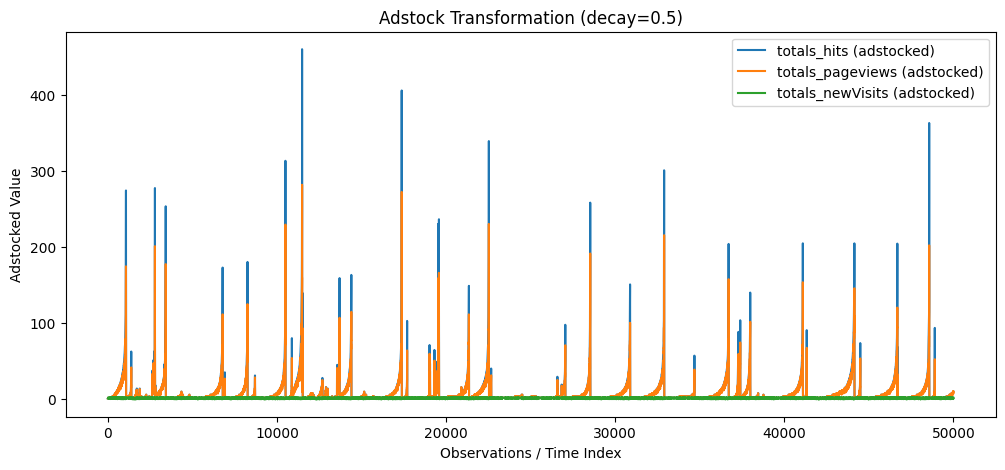

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from src.mmm_model import adstock_transform, saturation_transform

# Load the cleaned or analyzed data
df = pd.read_excel("../notebooks/outputs/analysed_data.xlsx")

# Choose numeric marketing variables to analyze
variables = ["totals_hits", "totals_pageviews", "totals_newVisits"]
decay_rate = 0.5

# Plot adstock transformations
plt.figure(figsize=(12, 5))
for var in variables:
    if var in df.columns:
        transformed = adstock_transform(df[var].fillna(0), decay=decay_rate)
        plt.plot(transformed, label=f"{var} (adstocked)")
plt.title(f"Adstock Transformation (decay={decay_rate})")
plt.xlabel("Observations / Time Index")
plt.ylabel("Adstocked Value")
plt.legend()
plt.show()


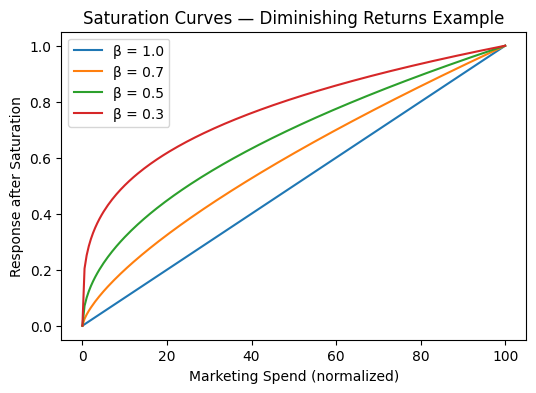

In [2]:
import numpy as np

x = np.linspace(0, 100, 200)
plt.figure(figsize=(6, 4))
for beta in [1.0, 0.7, 0.5, 0.3]:
    y = saturation_transform(x / x.max(), alpha=1.0, beta=beta)
    plt.plot(x, y, label=f"β = {beta}")
plt.title("Saturation Curves — Diminishing Returns Example")
plt.xlabel("Marketing Spend (normalized)")
plt.ylabel("Response after Saturation")
plt.legend()
plt.show()


Applied log1p transform to revenue for stable MMM fit.
🔧 totals_hits: best decay=0.30, beta=1.00 (RSS=9550.86)
🔧 totals_pageviews: best decay=0.10, beta=1.00 (RSS=9407.08)
🔧 totals_newVisits: best decay=0.90, beta=0.70 (RSS=11184.20)
Cleaned dtypes:
 float64    16
Name: count, dtype: int64

✅ Tuned MMM trained successfully with 15 predictors.

                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.191
Model:                            OLS   Adj. R-squared:                  0.191
Method:                 Least Squares   F-statistic:                     789.1
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        14:44:27   Log-Likelihood:                -28727.
No. Observations:               50000   AIC:                         5.749e+04
Df Residuals:                   49984   BIC:                         5.763e+04
Df Model:             

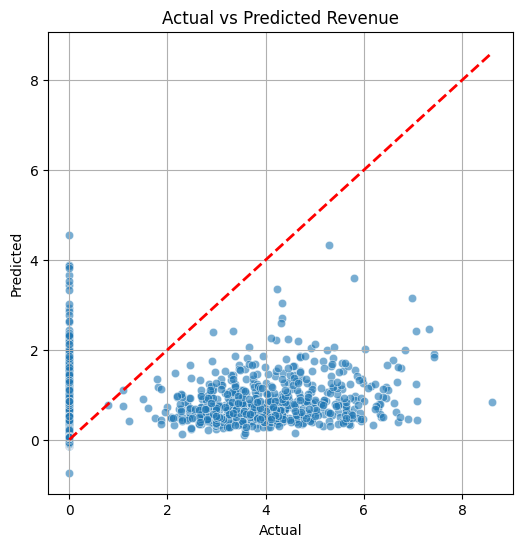

/workspaces/Marketing-Decision-Engine-From-Attribution-to-Spend-Optimization/src/mmm_visuals.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


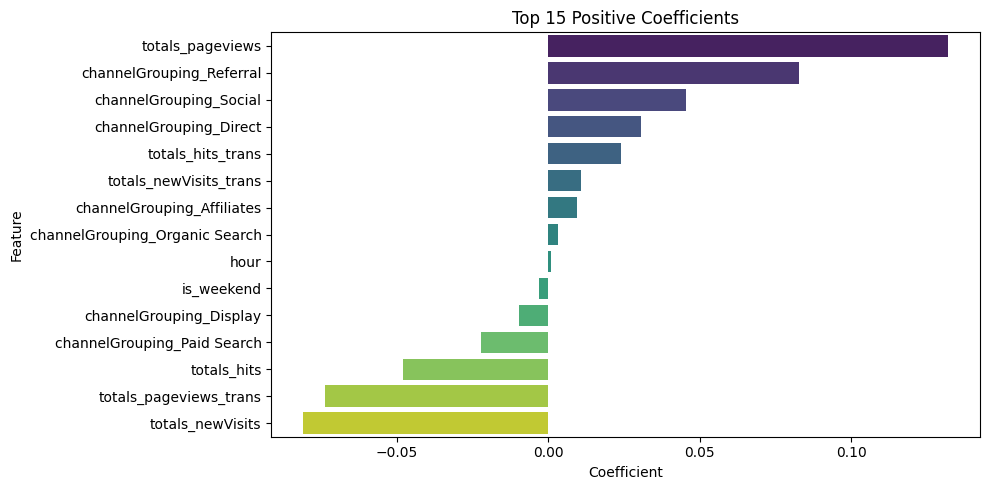

/workspaces/Marketing-Decision-Engine-From-Attribution-to-Spend-Optimization/src/mmm_visuals.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


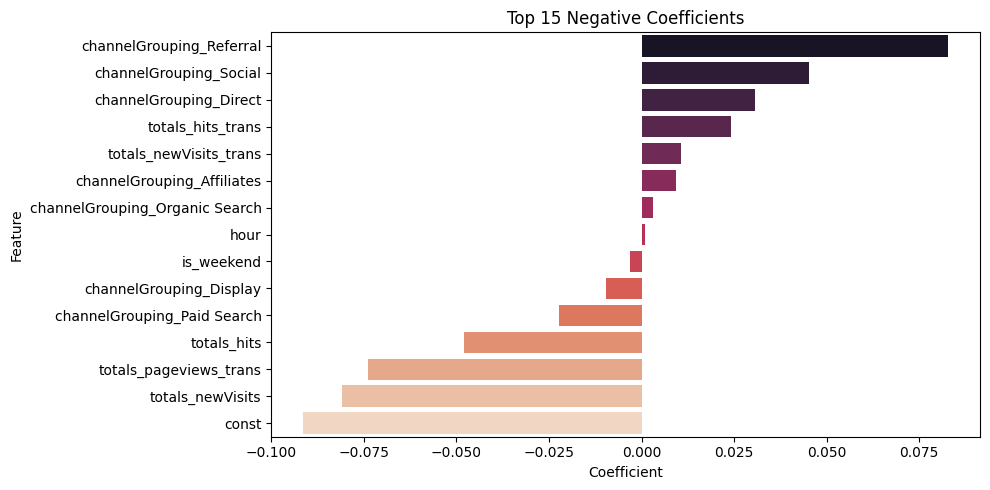

/workspaces/Marketing-Decision-Engine-From-Attribution-to-Spend-Optimization/src/mmm_visuals.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Elasticity", y="Feature", data=elas_df, palette="coolwarm")


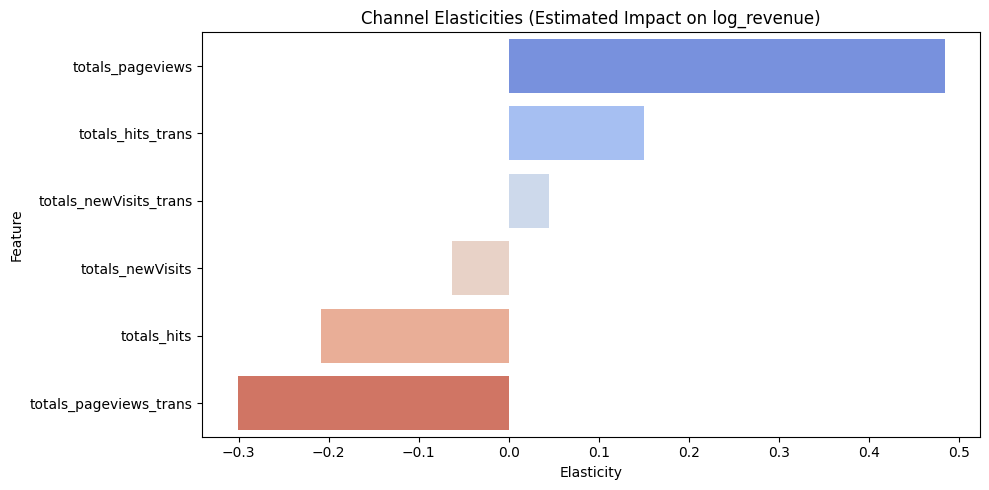

In [3]:
import pandas as pd
from src.mmm_model import run_mmm
from src.mmm_visuals import plot_actual_vs_predicted, plot_coefficients, plot_channel_elasticities

# 1. Load data
data = pd.read_excel("../notebooks/outputs/analysed_data.xlsx")

# 2. Train tuned MMM
model = run_mmm(data, dependent_var="log_revenue")

# 3. Retrieve the exact training matrices
X_trained = pd.DataFrame(model.model.exog, columns=model.model.exog_names)
y_trained = pd.Series(model.model.endog, name="log_revenue")

# 4. Visualize using aligned data
plot_actual_vs_predicted(model, X_trained, y_trained)
plot_coefficients(model, X_trained)
plot_channel_elasticities(model, X_trained)


In [4]:
from src.mmm_model import run_mmm
from src.mmm_optimizer import optimize_budget
import pandas as pd

data = pd.read_excel("../notebooks/outputs/analysed_data.xlsx")

# Run your tuned MMM model
model = run_mmm(data)

# Choose relevant marketing features as spend proxies
spend_vars = ["totals_hits", "totals_pageviews", "totals_newVisits"]

# Define total marketing budget (arbitrary units or normalized scale)
total_budget = 100000

result = optimize_budget(model, data, spend_vars, total_budget)

print("\nOptimal Spend Allocation:")
print(result["optimal_spends"])

print(f"\nPredicted log_revenue at optimum: {result['predicted_revenue']:.2f}")


Applied log1p transform to revenue for stable MMM fit.
🔧 totals_hits: best decay=0.30, beta=1.00 (RSS=9550.86)
🔧 totals_pageviews: best decay=0.10, beta=1.00 (RSS=9407.08)
🔧 totals_newVisits: best decay=0.90, beta=0.70 (RSS=11184.20)
Cleaned dtypes:
 float64    16
Name: count, dtype: int64

✅ Tuned MMM trained successfully with 15 predictors.

                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.191
Model:                            OLS   Adj. R-squared:                  0.191
Method:                 Least Squares   F-statistic:                     789.1
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        14:46:46   Log-Likelihood:                -28727.
No. Observations:               50000   AIC:                         5.749e+04
Df Residuals:                   49984   BIC:                         5.763e+04
Df Model:             

Applied log1p transform to revenue for stable MMM fit.
🔧 totals_hits: best decay=0.30, beta=1.00 (RSS=9550.86)
🔧 totals_pageviews: best decay=0.10, beta=1.00 (RSS=9407.08)
🔧 totals_newVisits: best decay=0.90, beta=0.70 (RSS=11184.20)
Cleaned dtypes:
 float64    16
Name: count, dtype: int64

✅ Tuned MMM trained successfully with 15 predictors.

                            OLS Regression Results                            
Dep. Variable:            log_revenue   R-squared:                       0.191
Model:                            OLS   Adj. R-squared:                  0.191
Method:                 Least Squares   F-statistic:                     789.1
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        14:48:08   Log-Likelihood:                -28727.
No. Observations:               50000   AIC:                         5.749e+04
Df Residuals:                   49984   BIC:                         5.763e+04
Df Model:             

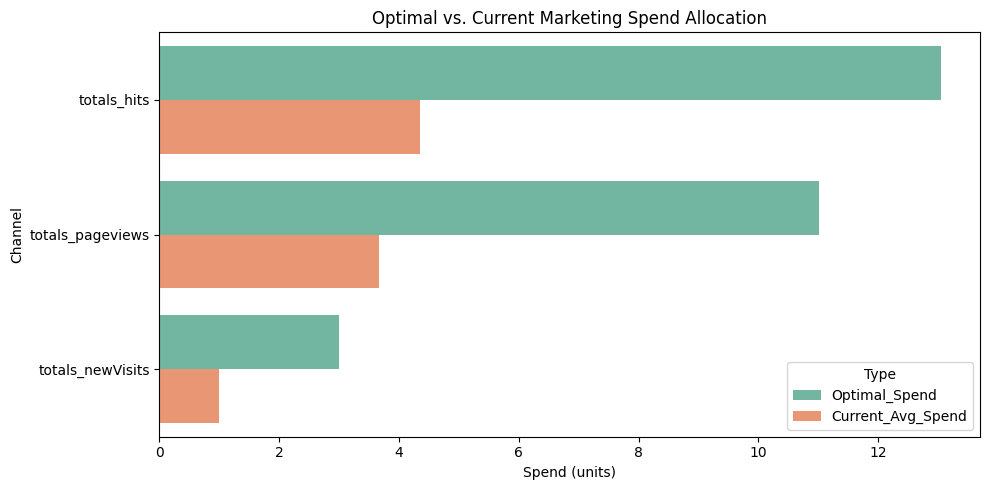

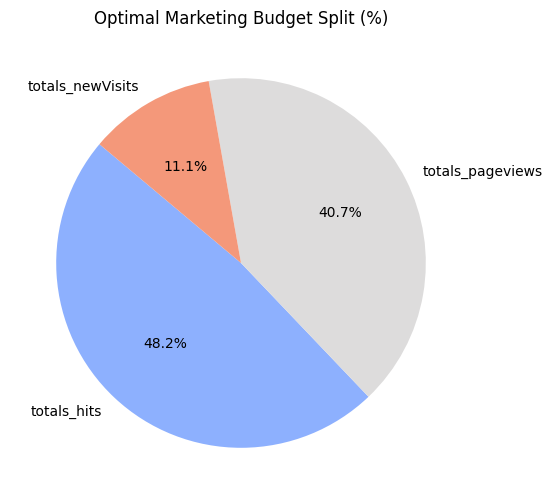

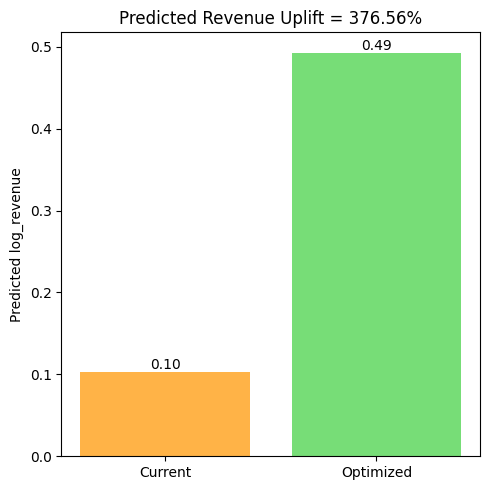

📈 Uplift: 0.3895 (376.56% increase from current)


In [5]:
from src.mmm_optimizer import optimize_budget
from src.mmm_optimizer_visuals import (
    plot_optimal_allocation,
    plot_allocation_percentages,
    show_uplift_comparison,
)
from src.mmm_model import run_mmm
import pandas as pd

data = pd.read_excel("../notebooks/outputs/analysed_data.xlsx")
model = run_mmm(data)

spend_vars = ["totals_hits", "totals_pageviews", "totals_newVisits"]
total_budget = 100000

result = optimize_budget(model, data, spend_vars, total_budget)
opt_df = result["optimal_spends"]

# Plots
plot_optimal_allocation(opt_df)
plot_allocation_percentages(opt_df)
show_uplift_comparison(model, data, spend_vars, result["optimal_spends"]["Optimal_Spend"].values)


Attribution Model Results


In [6]:
import pandas as pd
from src.attribution_model import run_rule_based_attribution

data = pd.read_excel("../notebooks/outputs/analysed_data.xlsx")

rb_attr = run_rule_based_attribution(
    data, channel_col="channelGrouping", revenue_col="revenue"
)
print("✅ Rule‑Based Attribution Results:")
print(rb_attr)


✅ Rule‑Based Attribution Results:
  channelGrouping   revenue    share_%
6        Referral  42982.34  51.612149
2          Direct  21176.42  25.428131
4  Organic Search  15501.09  18.613332
3         Display   2284.82   2.743556
5     Paid Search   1037.24   1.245493
7          Social    297.59   0.357339
0         (Other)      0.00   0.000000
1      Affiliates      0.00   0.000000


Predictive Modelling Results

In [3]:
import pandas as pd

# Read Excel file
df = pd.read_excel("../notebooks/outputs/analysed_data.xlsx")

# Save as CSV
df.to_csv("../data/processed/analysed_data.csv", index=False)

print("✅ Converted to CSV successfully")

✅ Converted to CSV successfully


In [2]:
import pandas as pd
import numpy as np
from src.predictive_model import run_predictive_model

# Load
data = pd.read_csv("../data/processed/analysed_data.csv", nrows=10000)

# Drop IDs / useless
drop_cols = ["sessionId", "fullVisitorId", "visitId", "city", "campaign", "keyword"]
data = data.drop(columns=drop_cols, errors="ignore")

# Drop datetime
data = data.drop(columns=data.select_dtypes(include=["datetime64", "datetime64[ns]"]).columns, errors="ignore")

# Create log revenue
if "log_revenue" not in data.columns and "revenue" in data.columns:
    data["log_revenue"] = np.log1p(data["revenue"])

# Fill NA first
data = data.fillna({
    col: 0 if pd.api.types.is_numeric_dtype(data[col]) else "Unknown"
    for col in data.columns
})

# ----------------------------
# Separate datasets
# ----------------------------

# Conversion dataset (STRICT)
conv_drop = [
    "revenue", "log_revenue", "transactions",
    "totals_transactionRevenue",
    "totals_hits", "totals_pageviews",
    "expected_revenue"
]

data_conv = data.drop(columns=conv_drop, errors="ignore")

# Revenue dataset
rev_drop = [
    "totals_transactionRevenue",
    "expected_revenue"
]

data_rev = data.drop(columns=rev_drop, errors="ignore")

# ----------------------------
# Sample
# ----------------------------
data_conv_sample = data_conv.sample(5000, random_state=42)
data_rev_sample = data_rev.sample(5000, random_state=42)

# ----------------------------
# Models
# ----------------------------

model_conv, results_conv, X_test_conv, y_test_conv = run_predictive_model(
    data_conv_sample,
    target="converted",
    use_random_forest=False
)

model_revenue, results_rev, X_test_rev, y_test_rev = run_predictive_model(
    data_rev_sample,
    target="log_revenue",
    use_random_forest=False
)
print("📊 Conversion Model Results:", results_conv)
print("💰 Revenue Model Results:", results_rev)

✅ Trained classification model using LogisticRegression
Results: {'model_type': 'classification', 'accuracy': 0.992, 'roc_auc': 0.9407762096774193}
✅ Trained regression model using LinearRegression
Results: {'model_type': 'regression', 'mae': 0.19511714457308443, 'rmse': np.float64(0.7510065969817353), 'r2': 0.7956770140801185}
📊 Conversion Model Results: {'model_type': 'classification', 'accuracy': 0.992, 'roc_auc': 0.9407762096774193}
💰 Revenue Model Results: {'model_type': 'regression', 'mae': 0.19511714457308443, 'rmse': np.float64(0.7510065969817353), 'r2': 0.7956770140801185}


In [2]:
import pandas as pd

pd.crosstab(data_conv_sample["converted"], data_conv_sample["is_returning_user"], normalize="columns")

is_returning_user,0,1
converted,,
0,0.994759,0.973815
1,0.005241,0.026185


In [3]:
probs = model_conv.predict_proba(X_test_conv)[:, 1]

print("Max prob:", probs.max())
print("Mean prob:", probs.mean())

Max prob: 0.04655709481315071
Mean prob: 0.00040739116483520425


In [4]:
probs = model_conv.predict_proba(X_test_conv)[:, 1]

for t in [0.05, 0.1, 0.2]:
    preds = (probs > t).astype(int)
    
    print(f"\nThreshold: {t}")
    from sklearn.metrics import classification_report
    print(classification_report(y_test_conv, preds))


Threshold: 0.05
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       992
           1       0.00      0.00      0.00         8

    accuracy                           0.99      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       0.98      0.99      0.99      1000


Threshold: 0.1
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       992
           1       0.00      0.00      0.00         8

    accuracy                           0.99      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       0.98      0.99      0.99      1000


Threshold: 0.2
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       992
           1       0.00      0.00      0.00         8

    accuracy                           0.99      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       0.98  

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

In [5]:
from sklearn.metrics import classification_report
print(classification_report(y_test_conv, model_conv.predict(X_test_conv)))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       992
           1       0.00      0.00      0.00         8

    accuracy                           0.99      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       0.98      0.99      0.99      1000



/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

In [7]:
from sklearn.metrics import classification_report

print(classification_report(y_test_conv, model_conv.predict(X_test_conv)))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       992
           1       0.00      0.00      0.00         8

    accuracy                           0.99      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       0.98      0.99      0.99      1000



/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

In [8]:
conversion_prob = model_conv.predict_proba(X_test_conv)[:, 1]
predicted_revenue = model_revenue.predict(X_test_rev)
expected_value = conversion_prob * predicted_revenue

In [9]:
df_eval = X_test_conv.copy()

df_eval["conversion_prob"] = conversion_prob
df_eval["predicted_revenue"] = predicted_revenue
df_eval["expected_value"] = expected_value

df_eval.sort_values("expected_value", ascending=False).head(10)

,visitNumber,device_isMobile,totals_visits,totals_bounces,totals_newVisits,trafficSource_isTrueDirect,trafficSource_adwordsClickInfo.page,trafficSource_adwordsClickInfo.isVideoAd,num_sessions_per_user,is_returning_user,...,trafficSource_adContent_{KeyWord:Google Drinkware},trafficSource_adContent_{KeyWord:Google Merchandise},day_of_week_Sunday,day_of_week_Thursday,engagement_level_high,engagement_level_low,engagement_level_medium,conversion_prob,predicted_revenue,expected_value
3418,7,False,1,0.0,0.0,1.0,0.0,0.0,1,0,...,False,False,False,True,True,False,False,0.009301,30.636893,0.284950
3409,3,False,1,0.0,0.0,1.0,0.0,0.0,2,1,...,False,False,False,True,True,False,False,0.006361,9.884474,0.062871
1056,2,False,1,0.0,0.0,1.0,0.0,0.0,2,1,...,False,False,False,False,True,False,False,0.002046,15.159233,0.031013
6663,3,False,1,0.0,0.0,1.0,0.0,0.0,1,0,...,False,False,False,False,True,False,False,0.003159,9.816222,0.031006
1008,1,False,1,0.0,1.0,0.0,0.0,0.0,1,0,...,False,False,False,False,True,False,False,0.002092,14.497062,0.030331
8181,1,True,1,0.0,1.0,0.0,1.0,0.0,1,0,...,False,False,True,False,True,False,False,0.046557,0.485379,0.022598
2805,1,False,1,0.0,1.0,0.0,0.0,0.0,1,0,...,False,False,False,True,False,True,False,0.013448,1.630125,0.021922
847,2,False,1,0.0,0.0,1.0,0.0,0.0,1,0,...,False,False,False,False,True,False,False,0.009592,0.992418,0.009520
1044,1,False,1,0.0,1.0,0.0,0.0,0.0,2,1,...,False,False,False,False,True,False,False,0.006110,1.503860,0.009188
1026,1,False,1,0.0,1.0,0.0,0.0,0.0,1,0,...,False,False,False,False,True,False,False,0.000870,10.109637,0.008793


In [10]:
df_eval["predicted_revenue"] = predicted_revenue[:len(df_eval)]

⚠️ This model does not provide feature importances.


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


<Figure size 600x500 with 0 Axes>

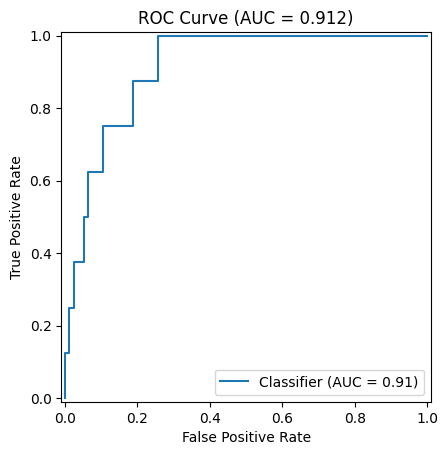

⚠️ This model does not provide feature importances.
      visitNumber  device_isMobile  totals_visits  totals_bounces  \
3418            7            False              1             0.0   
3409            3            False              1             0.0   
1056            2            False              1             0.0   
6663            3            False              1             0.0   
1008            1            False              1             0.0   
8181            1             True              1             0.0   
2805            1            False              1             0.0   
847             2            False              1             0.0   
1044            1            False              1             0.0   
1026            1            False              1             0.0   

      totals_newVisits  trafficSource_isTrueDirect  \
3418               0.0                         1.0   
3409               0.0                         1.0   
1056               0.0    

In [12]:
import pandas as pd
import numpy as np
from src.predictive_model import run_predictive_model
from src.predictive_visuals import plot_feature_importances, plot_roc_curve

# ----------------------------
# 6. VISUALS
# ----------------------------

plot_feature_importances(
    model_conv,
    X_test_conv.columns,
    top_n=15,
    title="Top 15 Features Influencing Conversion"
)

plot_roc_curve(model_conv, X_test_conv, y_test_conv)

plot_feature_importances(
    model_revenue,
    X_test_rev.columns,
    top_n=15,
    title="Top 15 Drivers of Revenue"
)

# ----------------------------
# 7. EXPECTED VALUE (FINAL LAYER)
# ----------------------------

conversion_prob = model_conv.predict_proba(X_test_conv)[:, 1]
predicted_revenue = model_revenue.predict(X_test_rev)

df_eval = X_test_conv.copy()
df_eval["conversion_prob"] = conversion_prob
df_eval["predicted_revenue"] = predicted_revenue[:len(df_eval)]
df_eval["expected_value"] = df_eval["conversion_prob"] * df_eval["predicted_revenue"]

print(df_eval.sort_values("expected_value", ascending=False).head(10))

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


<Figure size 600x500 with 0 Axes>

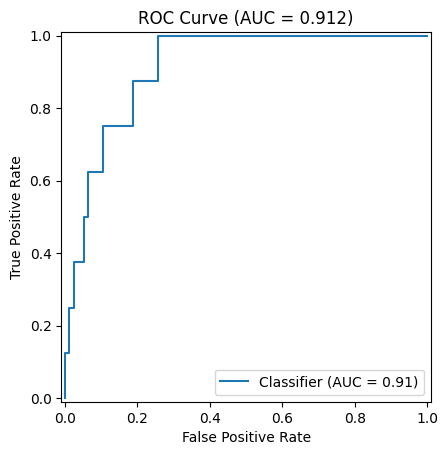

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


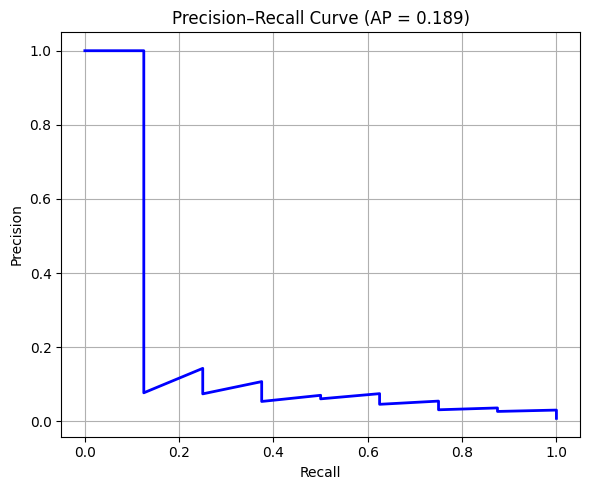

⚠️ This model does not provide feature importances.
⚠️ Partial dependence plots best suited for tree-based models (e.g., RandomForest, XGBoost).


In [15]:
from src.predictive_visuals import plot_feature_importances, plot_roc_curve,plot_feature_importances, plot_partial_dependence,plot_precision_recall

# ROC + PR
plot_roc_curve(model_conv, X_test_conv, y_test_conv)
plot_precision_recall(model_conv, X_test_conv, y_test_conv)

# Feature importance
plot_feature_importances(model_conv, X_test_conv.columns)

# ----------------------------
# 7. FIXED PARTIAL DEPENDENCE
# ----------------------------

# Pick meaningful features (NOT indices)
top_features = X_test_conv.columns[:3]

plot_partial_dependence(
    model_conv,
    X_test_conv,
    features=top_features,
    feature_names=X_test_conv.columns)

In [5]:
print(
    X_test_conv_clean.select_dtypes(exclude=[np.number]).columns
)

Index([], dtype='str')


Shape: (1000, 6710)
<class 'sklearn.linear_model._logistic.LogisticRegression'>


/tmp/ipykernel_3917/3866680387.py:62: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


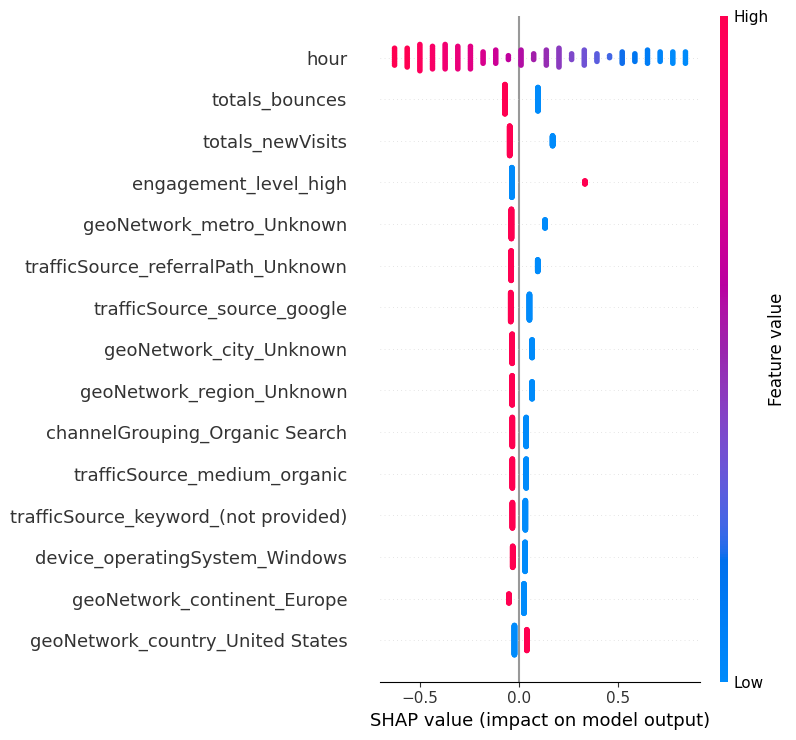

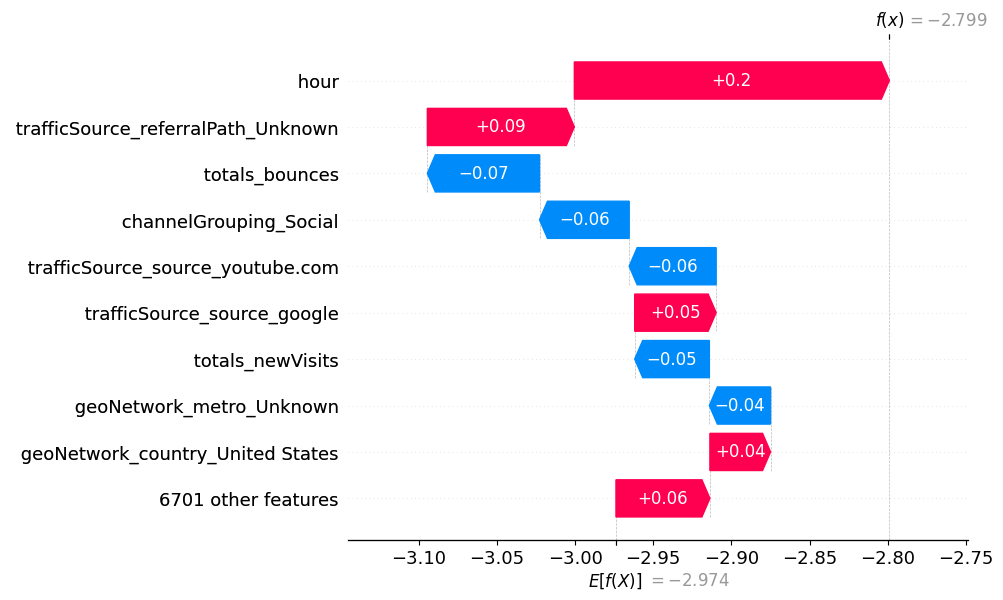

In [10]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt

# ---------------------------------------------------
# CLEAN DATA
# ---------------------------------------------------

X_test_conv_clean = X_test_conv.copy()

for col in X_test_conv_clean.columns:
    X_test_conv_clean[col] = pd.to_numeric(
        X_test_conv_clean[col],
        errors="coerce"
    )

X_test_conv_clean = X_test_conv_clean.fillna(0)

X_test_conv_clean = pd.DataFrame(
    X_test_conv_clean.to_numpy(dtype=np.float64),
    columns=X_test_conv_clean.columns
)

print("Shape:", X_test_conv_clean.shape)

# ---------------------------------------------------
# SMALL SAMPLE
# ---------------------------------------------------

X_sample = X_test_conv_clean.sample(
    200,
    random_state=42
)

# ---------------------------------------------------
# EXTRACT LOGISTIC REGRESSION MODEL
# ---------------------------------------------------

final_model = model_conv.named_steps[
    list(model_conv.named_steps.keys())[-1]
]

print(type(final_model))

# ---------------------------------------------------
# LINEAR SHAP EXPLAINER
# ---------------------------------------------------

explainer = shap.LinearExplainer(
    final_model,
    X_sample
)

# Calculate SHAP values
shap_values = explainer.shap_values(X_sample)

# ---------------------------------------------------
# GLOBAL FEATURE IMPORTANCE
# ---------------------------------------------------

shap.summary_plot(
    shap_values,
    X_sample,
    max_display=15
)

# ---------------------------------------------------
# LOCAL EXPLANATION
# ---------------------------------------------------

shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[5],
    feature_names=X_sample.columns,
    features=X_sample.iloc[5]
)